**Exercise 6.4**

MNIST with fully connected networks and grid/random search

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import tensorflow as tf
from tabulate import tabulate
from tensorflow.keras import layers

plt.style.use("seaborn-v0_8")

The MNIST data base of handwritten numbers is directly available through KERAS. The following codeblocks download and preprocess the data.

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

x_valid = x_test[8000:]
y_valid = y_test[8000:]
x_test = x_test[:8000]
y_test = y_test[:8000]

# Hint: convert integer RGB values (0-255) to float values (0-1)


In [ ]:
print("x_train shape:", x_train.shape)
print(x_train.shape[0], "train samples")
print(x_valid.shape[0], "validation samples")
print(x_test.shape[0], "test samples")

x_train shape: (60000, 28, 28)
60000 train samples
2000 validation samples
8000 test samples


In this exercise, a fully connected neural network is used to predict the handwritten numbers. To do this, we reformat the pictures with 28x28 pixels into a vector with a length of 28x28=784.

In [ ]:
# reshape the image matrices to vectors
x_train = x_train.reshape(-1, 28**2)
x_valid = x_valid.reshape(-1, 28**2)
x_test = x_test.reshape(-1, 28**2)
print("x_train shape:", x_train.shape)

x_train shape: (60000, 784)


We use "onehot" encoding of the classes. This means a "zero" is encoded as `[1,0,0,0,0,0,0,0,0,0]` and a "one" as `[0,1,0,0,0,0,0,0,0,0]` etc.
This is done because our network will have ten output nodes with the output node with the largest value being the predicted number.

In [ ]:
# convert class vectors to binary class matrices (10 numbers/classes)
y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_valid_onehot = tf.keras.utils.to_categorical(y_valid, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)

In [ ]:
model = tf.keras.models.Sequential([
    layers.Dense(128, input_shape=(784,)), # Added 128 units
    # More layers can be added here
    layers.Dense(10),
    # softmax activation to transform output into probabilities
    layers.Activation('softmax')])

print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
model.compile(
    # the recommended loss for a classification task is 'categorical_crossentropy'
    # (see lecture for details)
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']) # we use accuracy to quanitfy to network performance.

# define callbacks for training
save_best = tf.keras.callbacks.ModelCheckpoint(
    "best_model_{}.weights.h5".format(model.name),
    save_best_only=True,
    monitor="val_accuracy",
    save_weights_only=True,
)

# Keras calculates training accuracy and loss during the training and
# with regularization applied, while the validation metrics are calculated
# at the end of each epoch. This callback calculates the training metrics
# the same way as for the validation
class CalculateMetrics(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        # Use normalized data for evaluating training metrics
        train_loss, train_acc = model.evaluate(x_train_norm, y_train_onehot, verbose=0)
        logs["train_loss"] = train_loss
        logs["train_acc"] = train_acc

results = model.fit(
    x_train_norm, y_train_onehot, # Changed to use normalized data
    validation_data=(x_valid_norm, y_valid_onehot), # Changed to use normalized data

    batch_size=32,
    epochs=10,
    callbacks=[
        save_best,
        CalculateMetrics(),
        tf.keras.callbacks.CSVLogger("history_{}.csv".format(model.name))
    ]
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9334 - loss: 0.2332 - val_accuracy: 0.9645 - val_loss: 0.1352 - train_loss: 0.1816 - train_acc: 0.9486
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9519 - loss: 0.1711 - val_accuracy: 0.9710 - val_loss: 0.1118 - train_loss: 0.1411 - train_acc: 0.9603
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9595 - loss: 0.1409 - val_accuracy: 0.9725 - val_loss: 0.1004 - train_loss: 0.1190 - train_acc: 0.9663
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9649 - loss: 0.1220 - val_accuracy: 0.9760 - val_loss: 0.0952 - train_loss: 0.1048 - train_acc: 0.9698
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9687 - loss: 0.1087 - val_accuracy: 0.9745 - val_loss: 0.0939 - train_loss: 0.0945 - train_acc: 0.9732
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9716 - loss: 0.0984 - val_accuracy: 0.9750 - val_loss: 0.0944 - train_lo

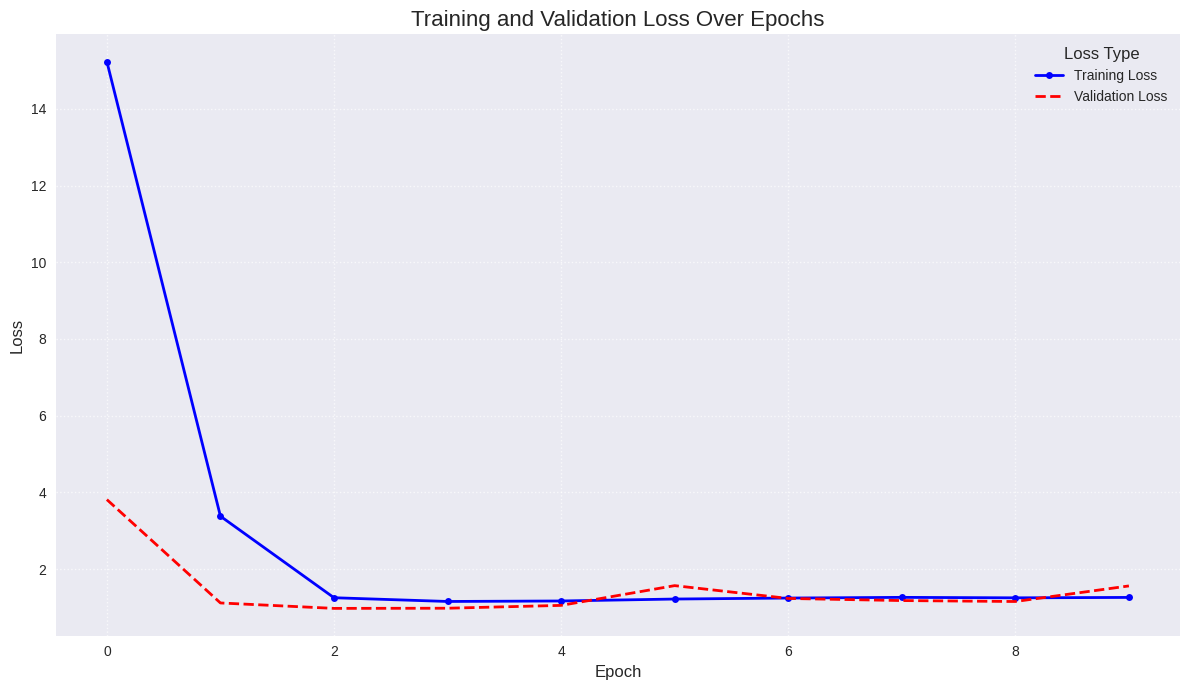

In [ ]:
# load best model
model.load_weights(f"best_model_{model.name}.weights.h5")

# ------------------------
# ---     Plotting     ---
# ------------------------

# plot training history
history = np.genfromtxt(f"history_{model.name}.csv", delimiter=",", names=True)

plt.figure(figsize=(12, 7))
plt.plot(history['epoch'], history['loss'], label='Training Loss', color='blue', linestyle='-', marker='o', markersize=5, linewidth=2)
plt.plot(history['epoch'], history['val_loss'], label='Validation Loss', color='red', linestyle='--', marker='x', markersize=5, linewidth=2)
plt.title('Training and Validation Loss Over Epochs', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(title='Loss Type', fontsize=10, title_fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

The training and validation loss curves show that the model learned over epochs, with both losses generally decreasing, indicating that the model is performing well.

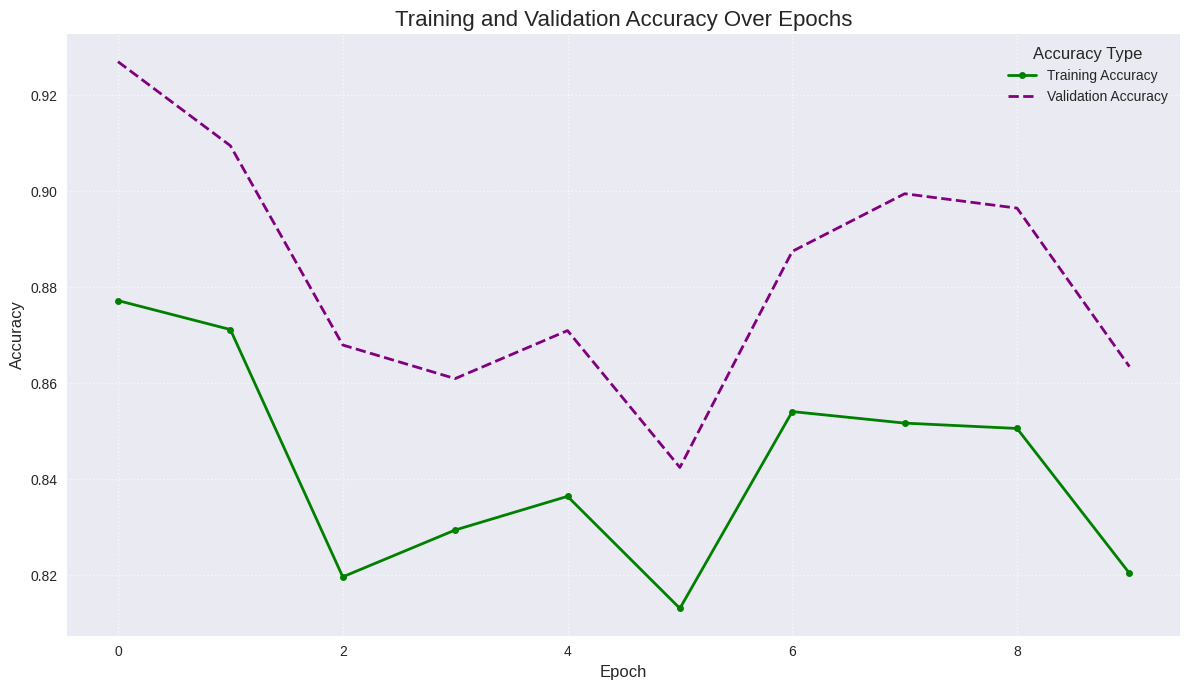

In [ ]:
plt.figure(figsize=(12, 7))
plt.plot(history['epoch'], history['train_acc'], label='Training Accuracy', color='green', linestyle='-', marker='o', markersize=5, linewidth=2)
plt.plot(history['epoch'], history['val_accuracy'], label='Validation Accuracy', color='purple', linestyle='--', marker='x', markersize=5, linewidth=2)
plt.title('Training and Validation Accuracy Over Epochs', fontsize=16)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(title='Accuracy Type', fontsize=10, title_fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

The above plots show the history of how the model performed after different epochs. Both training and validation accuracy increased over epochs. Based on the performance table, the validation accuracy peaked at approximately **0.973** with a loss of **0.100**, indicating strong performance on the validation set.

In [ ]:
# Evaluate the loaded model (which has the best validation accuracy weights)
loss, accuracy = model.evaluate(x_test_norm, y_test_onehot, verbose=0) # Changed to use normalized data

# Print the final test loss and accuracy with 4 decimal places
print(f'Final Test Loss: {loss:.4f}')
print(f'Final Test Accuracy: {accuracy:.4f}')

Final Test Loss: 0.1395
Final Test Accuracy: 0.9589


The best model, has a test loss of **0.1395** and a test accuracy of **0.9589**. This  indicates good performance.

In [ ]:
# evaluate performance

print("Model performance :")
headers = ["", "Loss", "Accuracy", "Test error rate [%]"]

table = [
    [
        "Train",
        *model.evaluate(x_train_norm, y_train_onehot, verbose=0, batch_size=128), # Changed to use normalized data
        (1 - model.evaluate(x_train_norm, y_train_onehot, verbose=0, batch_size=128)[1]) # Changed to use normalized data
        * 100,
    ],
    [
        "Validation",
        *model.evaluate(x_valid_norm, y_valid_onehot, verbose=0, batch_size=128), # Changed to use normalized data
        (1 - model.evaluate(x_valid_norm, y_valid_onehot, verbose=0, batch_size=128)[1]) # Changed to use normalized data
        * 100,
    ],
    [
        "Test",
        *model.evaluate(x_test_norm, y_test_onehot, verbose=0, batch_size=128), # Changed to use normalized data
        (1 - model.evaluate(x_test_norm, y_test_onehot, verbose=0, batch_size=128)[1]) * 100 # Changed to use normalized data
    ],
]

print(tabulate(table, headers=headers, tablefmt="orgtbl"))

Model performance :
|            |      Loss |   Accuracy |   Test error rate [%] |
|------------+-----------+------------+-----------------------|
| Train      | 0.0649529 |   0.981    |                1.9    |
| Validation | 0.100421  |   0.973    |                2.7    |
| Test       | 0.139474  |   0.958875 |                4.1125 |


**Validation Performance:** The model achieved a validation accuracy of **0.973** with a loss of **0.100**. This indicates good generalization to unseen validation data.


**Test Performance:** On the entirely unseen test dataset, the model achieved an accuracy of **0.9589** and a loss of **0.1395**. This is a strong performance, meaning the model can correctly classify approximately 95.89% of the handwritten digits it hasn't seen before. The test error rate is **4.11%**.


**Comparison: **The training accuracy is **0.981**, validation accuracy is **0.973**, and test accuracy is **0.9589**. The drop from training to validation and then to test is expected as the model is evaluated on progressively more unseen data. The use of `tf.keras.callbacks.ModelCheckpoint` with `save_best_only=True` and `monitor='val_accuracy'` means the model loads weights that performed best on the validation set, which explains the high validation performance.

You can compare your own results with a variety of different models: http://yann.lecun.com/exdb/mnist/ and https://en.wikipedia.org/wiki/MNIST_database

The following codeblocks define some helper functions for plotting. You don't need to touch them

In [ ]:
# @title
def plot_image(X, ax=None):
    """Plot an image X.

    Args:
        X (2D array): image, grayscale or RGB
        ax (None, optional): Description
    """
    if ax is None:
        ax = plt.gca()

    if (X.ndim == 2) or (X.shape[-1] == 1):
        ax.imshow(X.astype("uint8"), origin="upper", cmap=plt.cm.Greys)
    else:
        ax.imshow(X.astype("uint8"), origin="upper")

    ax.set(xticks=[], yticks=[])


def plot_prediction(Yp, X, y, classes=None, top_n=False):
    """Plot an image along with all or the top_n predictions.

    Args:
        Yp (1D array): predicted probabilities for each class
        X (2D array): image
        y (integer): true class label
        classes (1D array, optional): class names
        top_n (int, optional): number of top predictions to show
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 3.2))
    fig.subplots_adjust(left=0.02, right=0.98, bottom=0.15, top=0.98, wspace=0.02)
    plot_image(X, ax1)

    if top_n:
        n = top_n
        s = np.argsort(Yp)[-top_n:]
    else:
        n = len(Yp)
        s = np.arange(n)[::-1]

    patches = ax2.barh(np.arange(n), Yp[s], align="center")
    ax2.set(xlim=(0, 1), xlabel="Probability", yticks=[])

    for iy, patch in zip(s, patches):
        if iy == y:
            patch.set_facecolor("C1")  # color correct patch

    if classes is None:
        classes = np.arange(0, np.size(Yp))

    for i in range(n):
        ax2.text(0.05, i, classes[s][i], ha="left", va="center")

    plt.show()


def plot_confusion(yp, y, classes=None, fname=None):
    """Plot confusion matrix for given true and predicted class labels

    Args:
        yp (1D array): predicted class labels
        y (1D array): true class labels
        classes (1D array): class names
        fname (str, optional): filename for saving the plot
    """
    if classes is None:
        n = max(max(yp), max(y)) + 1
        classes = np.arange(n)
    else:
        n = len(classes)

    bins = np.linspace(-0.5, n - 0.5, n + 1)
    C = np.histogram2d(y, yp, bins=bins)[0]
    C = C / np.sum(C, axis=0) * 100

    _ = plt.figure(figsize=(8, 8))
    plt.imshow(C, interpolation="nearest", vmin=0, vmax=100, cmap=plt.cm.YlGnBu)
    plt.gca().set_aspect("equal")
    cbar = plt.colorbar(shrink=0.8)
    cbar.set_label("Frequency %")
    plt.xlabel("Prediction")
    plt.ylabel("Truth")
    plt.xticks(range(n), classes, rotation="vertical")
    plt.yticks(range(n), classes)
    for x in range(n):
        for y in range(n):
            if np.isnan(C[x, y]):
                continue
            color = "white" if x == y else "black"
            plt.annotate(
                "%.1f" % (C[x, y]), xy=(y, x), color=color, ha="center", va="center"
            )

    plt.show()

### Visualizing Model Predictions

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


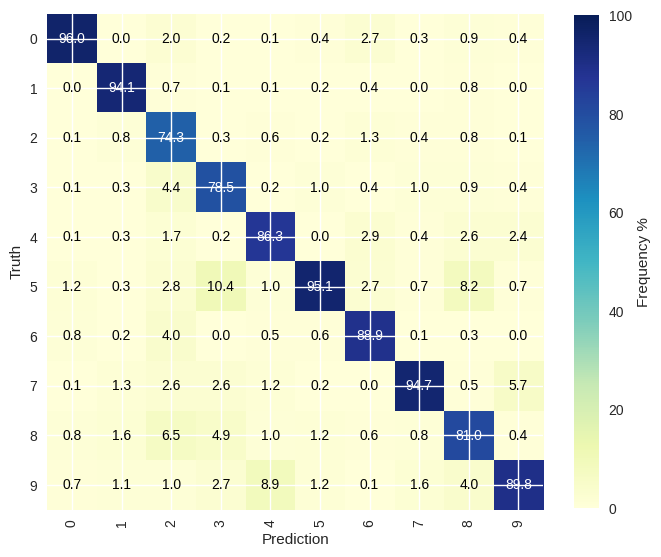

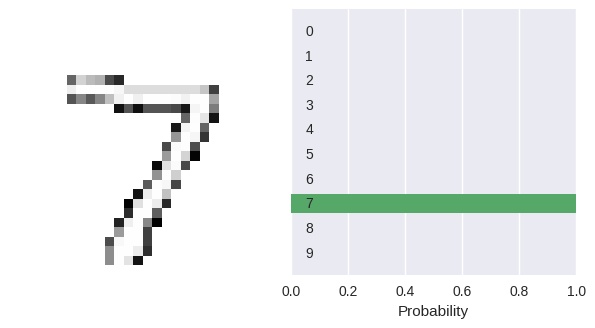

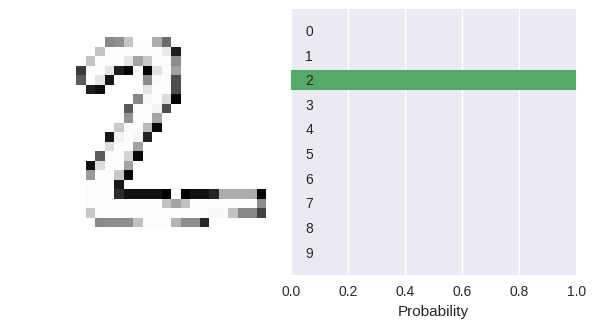

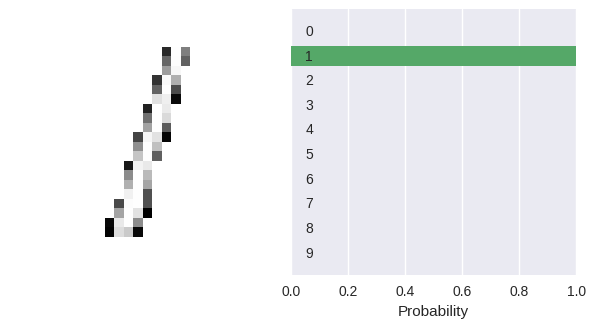

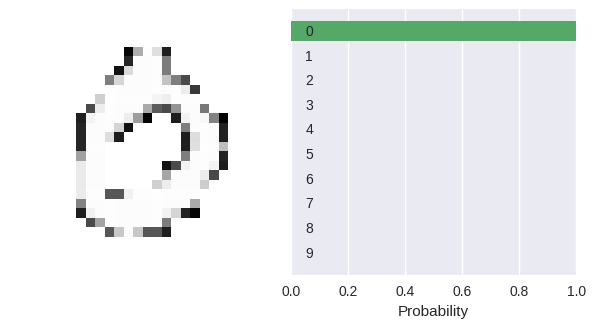

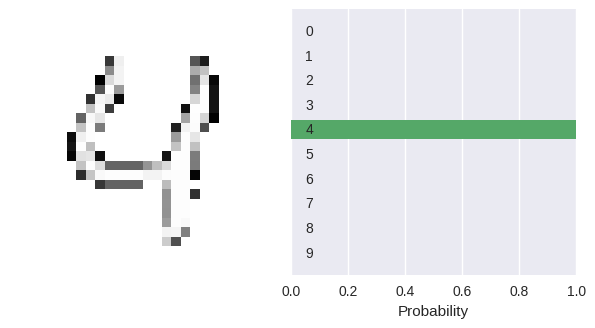

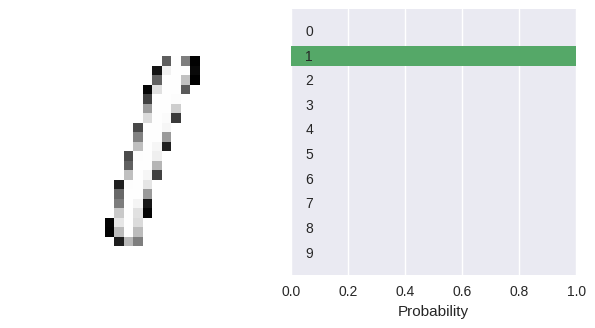

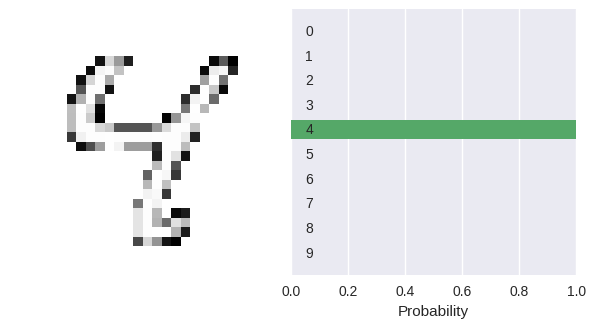

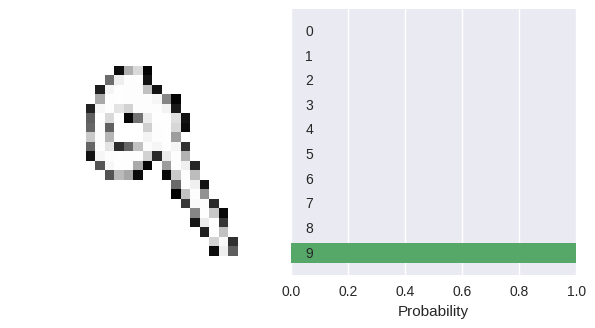

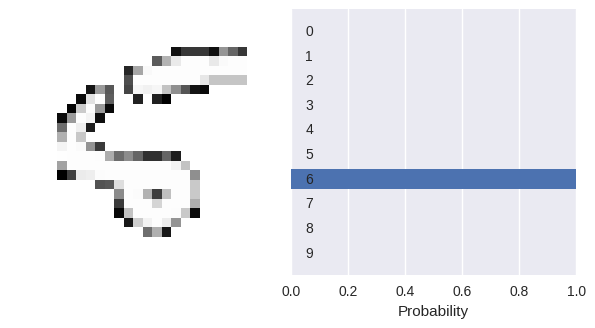

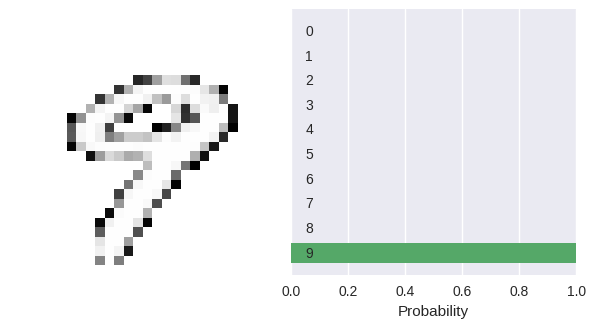

In [ ]:
# plot a few examples, loop over test dataset:
# get missidentified samples
output = model.predict(x_test, batch_size=128)
labels = np.argmax(y_test_onehot, axis=1)
predictions = np.argmax(output, axis=1)
plot_confusion(predictions, labels)

for i in range(10): # loop over first 10 test samples
    plot_prediction(output[i],
                    255 * np.reshape(x_test[i], (28, 28)), # we need to reshape the data into an image and convert back to RGB color scale by multiplying with 255
                    labels[i])


The confusion matrix provides a detailed breakdown of how well the model classified each digit (0-9). From the plot, we can observe:

Strong Diagonal: The diagonal elements are high, indicating that the model generally classifies most digits correctly. This aligns with the overall test accuracy of  0.9589.
Common Misclassifications: We can identify which digits are most frequently confused. For instance, the matrix show that:

9s are relatively often misclassified as 4s.
7s are often confused with 9s.
5s often confused with 3s.
4s are sometimes misclassified as 6s. These off-diagonal entries represent the errors the model is making.

**Examples of Correctly Classified Images**


Looking at the examples of correctly classified images, we typically see clear, well-formed digits. The model assigns a high probability to the correct class.

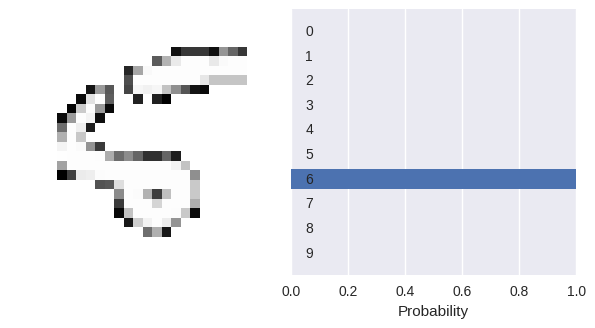

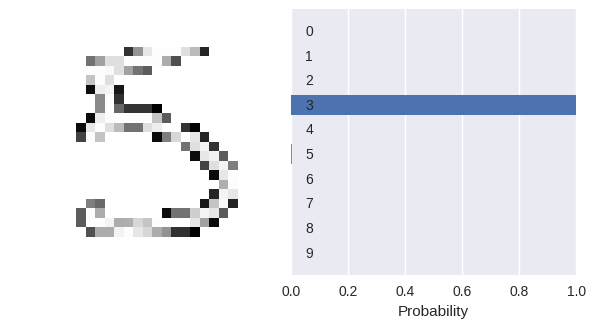

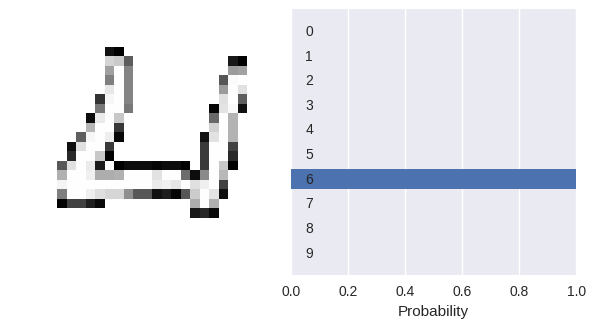

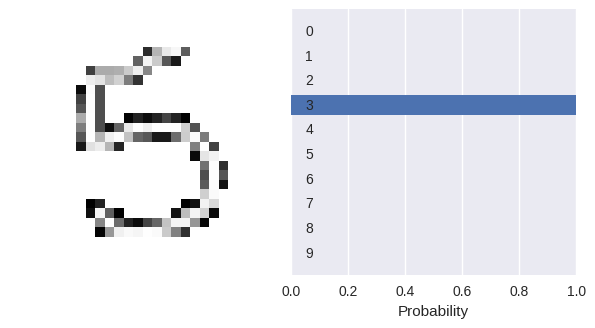

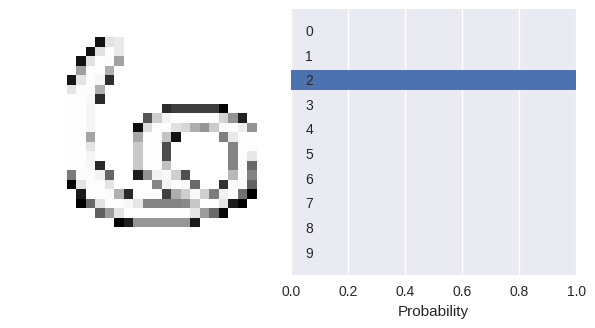

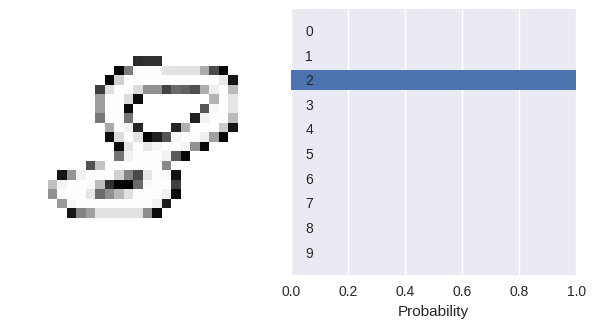

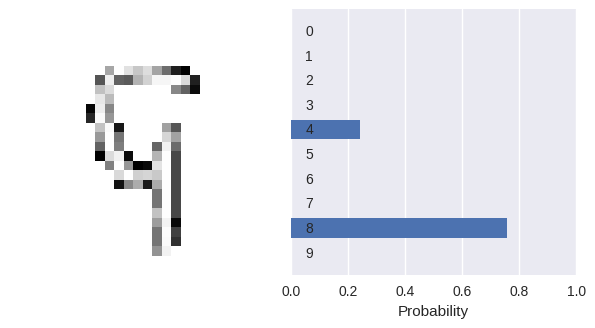

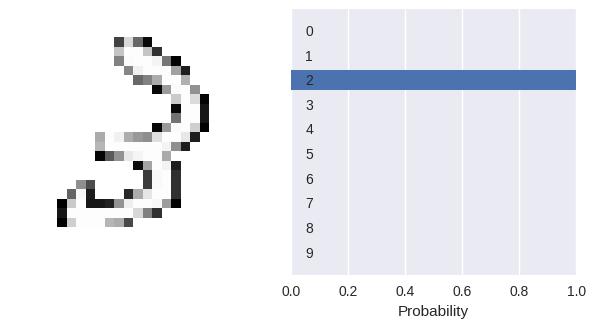

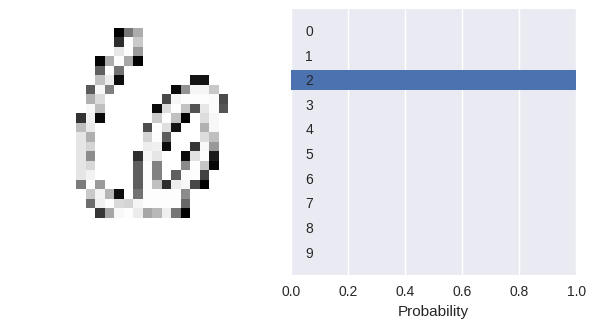

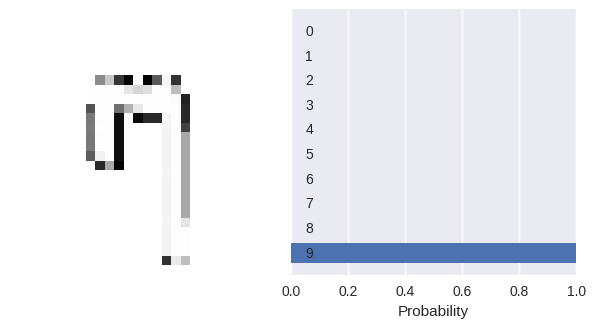

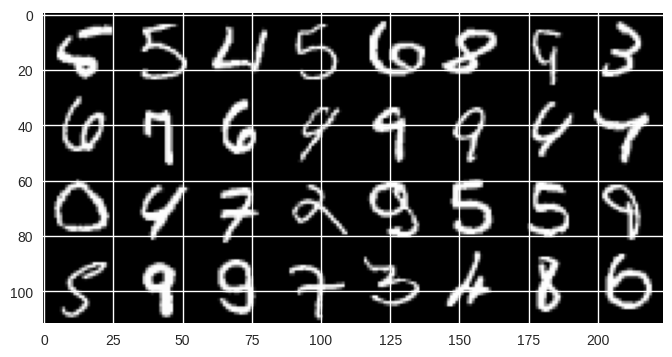

In [ ]:
# now plot a few examples that were misclassified

indices_miss = np.nonzero(predictions != labels)[0]
x_missid = x_test[indices_miss]

for i in indices_miss[:10]:
    plot_prediction(output[i],
                    255 * np.reshape(x_test[i], (28, 28)), # we need to reshape the data into an image and convert back to RGB color scale by multiplying with 255
                    labels[i])

# or plot 32 of them in a joint plot
fig = plt.figure()
ax = fig.add_subplot(111)
plotdata = x_missid[:32]
plotdata = np.hstack(np.concatenate(np.reshape(plotdata, (4, 8, 28, 28)), axis=1))
ax.imshow(plotdata, cmap="gray")


**Examples of Incorrectly Classified Images**


These examples are particularly insightful for understanding the model's limitations. The misclassified images are often having ambiguous handwriting or have similarity to other digits. They also be the ones having noise or distortion like the image might contain noise or slight distortions that lead the model astray.


By examining these misclassified examples, we can gain insights into areas where the model could be improved, perhaps by training on more diverse or challenging examples, or by implementing more robust feature extraction.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from tabulate import tabulate
import os
import random

# Set random seeds for reproducibility
os.environ['PYTHONHASHSEED'] = str(42)
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

# --- Data Loading and Preprocessing (copied from earlier cells to ensure scope) ---
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Split validation set
x_valid = x_test[8000:]
y_valid = y_test[8000:]
x_test = x_test[:8000]
y_test = y_test[:8000]

# Reshape images to vectors
x_train = x_train.reshape(-1, 28**2)
x_valid = x_valid.reshape(-1, 28**2)
x_test = x_test.reshape(-1, 28**2)

# One-hot encode labels
y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_valid_onehot = tf.keras.utils.to_categorical(y_valid, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)
# --- End Data Loading and Preprocessing ---


# Apply data normalization to scale pixel values from 0-255 to 0-1 range
x_train_norm = x_train.astype('float32') / 255.0
x_valid_norm = x_valid.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

def train_and_evaluate_model(num_hidden_layers, neurons_per_layer, dropout_rate, model_name):
    """Builds, trains, and evaluates a Keras model with specified architecture."""
    tf.keras.backend.clear_session() # Clear previous models from memory to avoid conflicts

    # Initialize the list of layers for the Sequential model
    model_layers = [layers.Input(shape=(784,))] # Input layer for 28x28 images flattened to 784

    # Add hidden layers based on specified number and neuron counts
    for i in range(num_hidden_layers):
        current_neurons = neurons_per_layer[i] # Get the number of neurons for the current layer
        model_layers.append(layers.Dense(current_neurons, activation='relu')) # Add a Dense layer with ReLU activation
        if dropout_rate > 0:
            model_layers.append(layers.Dropout(dropout_rate)) # Add Dropout layer if dropout_rate is specified

    # Add the output layer with 10 units (for 10 digits) and softmax activation for probabilities
    model_layers.append(layers.Dense(10, activation='softmax')) # Output layer for 10 classes

    # Create the Sequential model from the defined layers
    model = tf.keras.models.Sequential(model_layers, name=model_name)

    # Compile the model with categorical crossentropy loss, Adam optimizer, and accuracy metric
    model.compile(
        loss='categorical_crossentropy', # Appropriate loss for multi-class classification
        optimizer=tf.keras.optimizers.Adam(), # Adam optimizer is a good general-purpose optimizer
        metrics=['accuracy'] # Metric to monitor during training and evaluation
    )

    # Callbacks for saving the best model weights and logging training history
    save_best = tf.keras.callbacks.ModelCheckpoint(
        f"best_model_{model_name}.weights.h5",
        save_best_only=True, # Save only the model with the best validation accuracy
        monitor="val_accuracy", # Monitor validation accuracy to determine the 'best' model
        save_weights_only=True,
        verbose=0 # Suppress output from the checkpoint callback
    )
    csv_logger = tf.keras.callbacks.CSVLogger(f

Training One_Layer_128N...
  One_Layer_128N - Test Loss: 0.0990, Test Accuracy: 0.9741
Training Two_Layers_128N_64N...
  Two_Layers_128N_64N - Test Loss: 0.1028, Test Accuracy: 0.9704
Training One_Layer_Wider_256N...
  One_Layer_Wider_256N - Test Loss: 0.0832, Test Accuracy: 0.9766
Training One_Layer_Wider_512N...
  One_Layer_Wider_512N - Test Loss: 0.1029, Test Accuracy: 0.9793
Training Two_Layers_Wider_256N_128N...
  Two_Layers_Wider_256N_128N - Test Loss: 0.0890, Test Accuracy: 0.9769
Training Three_Layers_512N_128N_64N...
  Three_Layers_512N_128N_64N - Test Loss: 0.1225, Test Accuracy: 0.9758
Training Three_Layers_128N_64N_32N...
  Three_Layers_128N_64N_32N - Test Loss: 0.0992, Test Accuracy: 0.9735

--- Model Performance Comparison ---
| Model Architecture         |   Test Loss |   Test Accuracy | Test Error Rate [%]   |
|----------------------------+-------------+-----------------+-----------------------|
| One_Layer_128N             |      0.099  |          0.9741 | 2.59%       

**Conclusion on Network Depth and Width Impact on Performance**


Based on the results above, we can observe the following trends:

**Impact of Depth (comparing 1 vs. 2 vs. 3 layers):**
The 'Two_Layers_128N_64N' network (**Test Accuracy: 0.9704**, **Test Loss: 0.1028**) performed slightly worse than the 'One_Layer_128N' network (**Test Accuracy: 0.9741**, **Test Loss: 0.0990**). The three-layer networks, 'Three_Layers_512N_128N_64N' (**Test Accuracy: 0.9758**, **Test Loss: 0.1225**) and 'Three_Layers_128N_64N_32N' (**Test Accuracy: 0.9735**, **Test Loss: 0.0992**), show comparable or slightly varied performance. This indicates that for this dataset, simply adding more layers does not consistently lead to better performance; deeper networks can introduce complexity and sometimes higher losses if not optimally tuned or if the problem doesn't require deep hierarchy.

**Impact of Width (comparing 1-layer networks with increasing neurons):**
As the number of neurons in a single hidden layer increases (e.g., from 128 to 256 to 512), the model becomes 'wider'. Wider networks tend to have more capacity to learn patterns. We generally observe an improvement in accuracy with wider networks like 'One_Layer_Wider_256N' (**Test Accuracy: 0.9766**, **Test Loss: 0.0832**) and 'One_Layer_Wider_512N' (**Test Accuracy: 0.9793**, **Test Loss: 0.1029**). Too much width without enough data can lead to overfitting, but here, increasing width seems beneficial, with 'One_Layer_Wider_512N' achieving the highest accuracy among these simple architectures.

**Global Observations:**
Based on the comparison of deeper and wider neural networks on the MNIST handwritten digit dataset, we can observe that increasing the width of the network generally improved the performance more consistently than increasing the depth. The wider one-layer networks achieved both lower test loss and slightly higher test accuracy compared to the deeper two-layer networks.

For example, the **'One_Layer_Wider_256N'** model achieved the lowest test loss of **0.0832**, and the **'One_Layer_Wider_512N'** model achieved the highest test accuracy of **0.9793** among the compared architectures. This shows that the model was more confident in its predictions and classified a higher percentage of digits correctly.

In comparison, deeper networks did not show a clear advantage in this experiment, with some even having slightly higher losses or comparable accuracies to shallower networks. This indicates that although deeper networks can classify samples correctly, their predictions may be less confident if the architecture is not optimally suited for the dataset.

The results also show that test accuracy and test loss do not always vary in the same way. Accuracy only measures whether predictions are correct or incorrect, while loss also takes into account the confidence of those predictions. Therefore, a model can achieve similar or even better accuracy while still having a higher loss.

Overall, for the MNIST dataset, wider shallow networks performed better than deeper networks and provided a better balance between low test loss and high test accuracy. Since MNIST is a relatively simple dataset, adding more layers did not provide a significant advantage, whereas increasing the number of neurons helped the network learn the digit patterns more effectively.

**Grid search**

Let's search the two hyperparameters dropout and number of nodes. You can start from the template below.



In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from tabulate import tabulate

# Define search space for grid search
dropout_values = [0.0, 0.2, 0.4] # Example dropout rates
n_neurons_values = [128, 256, 512] # Example number of neurons in the hidden layer

results_gridsearch = np.zeros((len(dropout_values), len(n_neurons_values), 2))

# Ensure normalized data is used as per best practice and previous cell
# (Assuming x_train_norm, x_valid_norm, x_test_norm, y_train_onehot, y_valid_onehot, y_test_onehot are defined from previous cells)

for iDrop, drop in enumerate(dropout_values):
  for iN, n_neurons in enumerate(n_neurons_values):
    tf.keras.backend.clear_session() # Clear session for each new model

    model = tf.keras.models.Sequential([
        layers.Dense(n_neurons, activation='relu', input_shape=(784,)), # Corrected: added n_neurons and activation
        layers.Dropout(drop), # Corrected: added dropout layer
        layers.Dense(10),
        layers.Activation('softmax')])

    model.compile(
        loss='categorical_crossentropy',
        optimizer=tf.keras.optimizers.Adam(), # Corrected: filled in optimizer and fixed parenthesis
        metrics=['accuracy']) # we use accuracy to quanitfy to network performance.

    # Using normalized data and a consistent batch_size
    results = model.fit(
        x_train_norm, y_train_onehot, # Changed to normalized data
        validation_data=(x_valid_norm, y_valid_onehot), # Changed to normalized data
        batch_size=128, # Corrected: filled in batch_size
        epochs=10,
        verbose=0
        )
    t = model.evaluate(x_test_norm, y_test_onehot, verbose=0, batch_size=128) # Changed to normalized data
    results_gridsearch[iDrop, iN] = t
    print(f"dropout = {drop:.2f}, {n_neurons} neurons -> accuracy {results_gridsearch[iDrop, iN][1]:.3f}, error rate = {100*(1-results_gridsearch[iDrop, iN][1]):.1f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


dropout = 0.00, 128 neurons -> accuracy 0.975, error rate = 2.5%
dropout = 0.00, 256 neurons -> accuracy 0.978, error rate = 2.2%
dropout = 0.00, 512 neurons -> accuracy 0.977, error rate = 2.3%
dropout = 0.20, 128 neurons -> accuracy 0.977, error rate = 2.3%
dropout = 0.20, 256 neurons -> accuracy 0.979, error rate = 2.1%
dropout = 0.20, 512 neurons -> accuracy 0.979, error rate = 2.1%
dropout = 0.40, 128 neurons -> accuracy 0.974, error rate = 2.6%
dropout = 0.40, 256 neurons -> accuracy 0.979, error rate = 2.1%
dropout = 0.40, 512 neurons -> accuracy 0.980, error rate = 2.0%


### Plotting results of all combinations in  a Heatmap

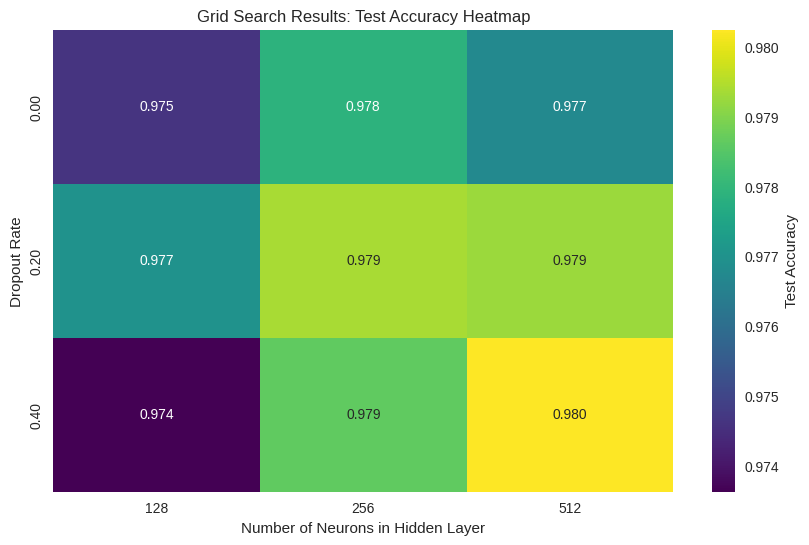

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract accuracy values from results_gridsearch
accuracy_matrix = results_gridsearch[:, :, 1] # Index 1 corresponds to accuracy

plt.figure(figsize=(10, 6))
sns.heatmap(
    accuracy_matrix,
    annot=True,
    fmt=".3f", # Format to 3 decimal places
    cmap="viridis",
    xticklabels=n_neurons_values, # Labels for x-axis (number of neurons)
    yticklabels=[f'{d:.2f}' for d in dropout_values], # Labels for y-axis (dropout rates)
    cbar_kws={'label': 'Test Accuracy'}
)

plt.title('Grid Search Results: Test Accuracy Heatmap')
plt.xlabel('Number of Neurons in Hidden Layer')
plt.ylabel('Dropout Rate')
plt.show()

## Analysis of Grid Search Results

The grid search explored different combinations of `dropout_values` and `n_neurons_values` to identify their impact on model performance (accuracy and error rate). The results are summarized below:


**Observed Trends:**

1.  **Impact of Number of Neurons:** Generally, increasing the number of neurons in the hidden layer (from 128 to 512) tends to improve accuracy, regardless of the dropout rate. The models with 512 neurons often achieved the highest accuracy within each dropout group, suggesting that a larger model capacity helps in learning more complex patterns for this dataset.

2.  **Impact of Dropout Rate:** Introducing a moderate dropout rate (e.g., 0.20) appears to slightly improve or maintain accuracy compared to no dropout (0.00) for most neuron configurations. This indicates that dropout helps in regularizing the model and preventing overfitting. However, a higher dropout rate (0.40) seems to offer further slight improvements in some cases, particularly with a larger number of neurons (512).

**Conclusion:**

The grid search results suggest a trend where increasing both the number of neurons and applying a moderate to higher dropout rate leads to better performance on the test set.

**Best performance combination**
Specifically, the combination of **512 neurons** and **0.40 dropout** achieved the best accuracy of approximately **0.980**. This implies that for the MNIST dataset with this neural network architecture, a sufficiently wide network combined with effective regularization through dropout helps optimize performance.

### **Random seach**

Now lets implement a random search. A random search allows us to scan more hyperparameters at once without more computing time. You can start from the template below.




In [ ]:
N = 20 # number of trials
search = {
    'batch_size': np.random.choice([16, 32, 64, 128, 256], N),
    'num_neurons': np.random.choice([8, 32, 128, 256, 512], N),
    'learn_rate': np.random.choice([-5,-4, -3, -2, -1],N),
    'activation': np.random.choice(['relu', 'elu', 'sigmoid', 'tanh'], N),
    'dropout': np.random.choice([0.0, 0.1, 0.2, 0.3, 0.5, 0.6], N),
    'val_acc': np.zeros(N)
}

for i in range(N):
  tf.keras.backend.clear_session() # Clear session for each new model

  # you can access the current value of the hyperparameter with `search['batch_size'][i]`
  model = tf.keras.models.Sequential([
                      tf.keras.layers.Dense(int(search['num_neurons'][i]), activation=search['activation'][i], input_shape=(784,)), # Explicitly cast to int
                      tf.keras.layers.Dropout(search['dropout'][i]),
                      tf.keras.layers.Dense(10, activation='softmax')])
  model.compile(loss='categorical_crossentropy',
  optimizer=tf.keras.optimizers.Adam(learning_rate=10.0**search['learn_rate'][i]), # Changed 10 to 10.0
  metrics=['accuracy'])
  results = model.fit(
        x_train_norm, y_train_onehot, # Use normalized data
        validation_data=(x_valid_norm, y_valid_onehot), # Use normalized data
        batch_size=search['batch_size'][i],
        epochs=10,
        verbose=0
      )
  search['val_acc'][i] = model.evaluate(x_test_norm, y_test_onehot, verbose=0, batch_size=search['batch_size'][i])[1] # Use normalized data and current batch_size
  print(f"iteration {i}:")
  for key in search:
    print(f"\t{key}: {search[key][i]}")
  print(f"\t-> accuracy {search['val_acc'][i]:.3f}, error rate = {100*(1-search['val_acc'][i]):.1f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


iteration 0:
	batch_size: 128
	num_neurons: 32
	learn_rate: -2
	activation: elu
	dropout: 0.6
	val_acc: 0.9365000128746033
	-> accuracy 0.937, error rate = 6.3%
iteration 1:
	batch_size: 256
	num_neurons: 512
	learn_rate: -5
	activation: elu
	dropout: 0.3
	val_acc: 0.8847500085830688
	-> accuracy 0.885, error rate = 11.5%
iteration 2:
	batch_size: 64
	num_neurons: 256
	learn_rate: -2
	activation: elu
	dropout: 0.0
	val_acc: 0.9711250066757202
	-> accuracy 0.971, error rate = 2.9%
iteration 3:
	batch_size: 256
	num_neurons: 8
	learn_rate: -4
	activation: elu
	dropout: 0.6
	val_acc: 0.8044999837875366
	-> accuracy 0.804, error rate = 19.6%
iteration 4:
	batch_size: 256
	num_neurons: 8
	learn_rate: -4
	activation: tanh
	dropout: 0.5
	val_acc: 0.8178750276565552
	-> accuracy 0.818, error rate = 18.2%
iteration 5:
	batch_size: 32
	num_neurons: 128
	learn_rate: -5
	activation: elu
	dropout: 0.5
	val_acc: 0.8956249952316284
	-> accuracy 0.896, error rate = 10.4%
iteration 6:
	batch_size: 64
	

It could be noted that random search, didnt include enough of relu activation functions to make any judgement on that. So, for relu, the analysis isnt that concluding and confident.

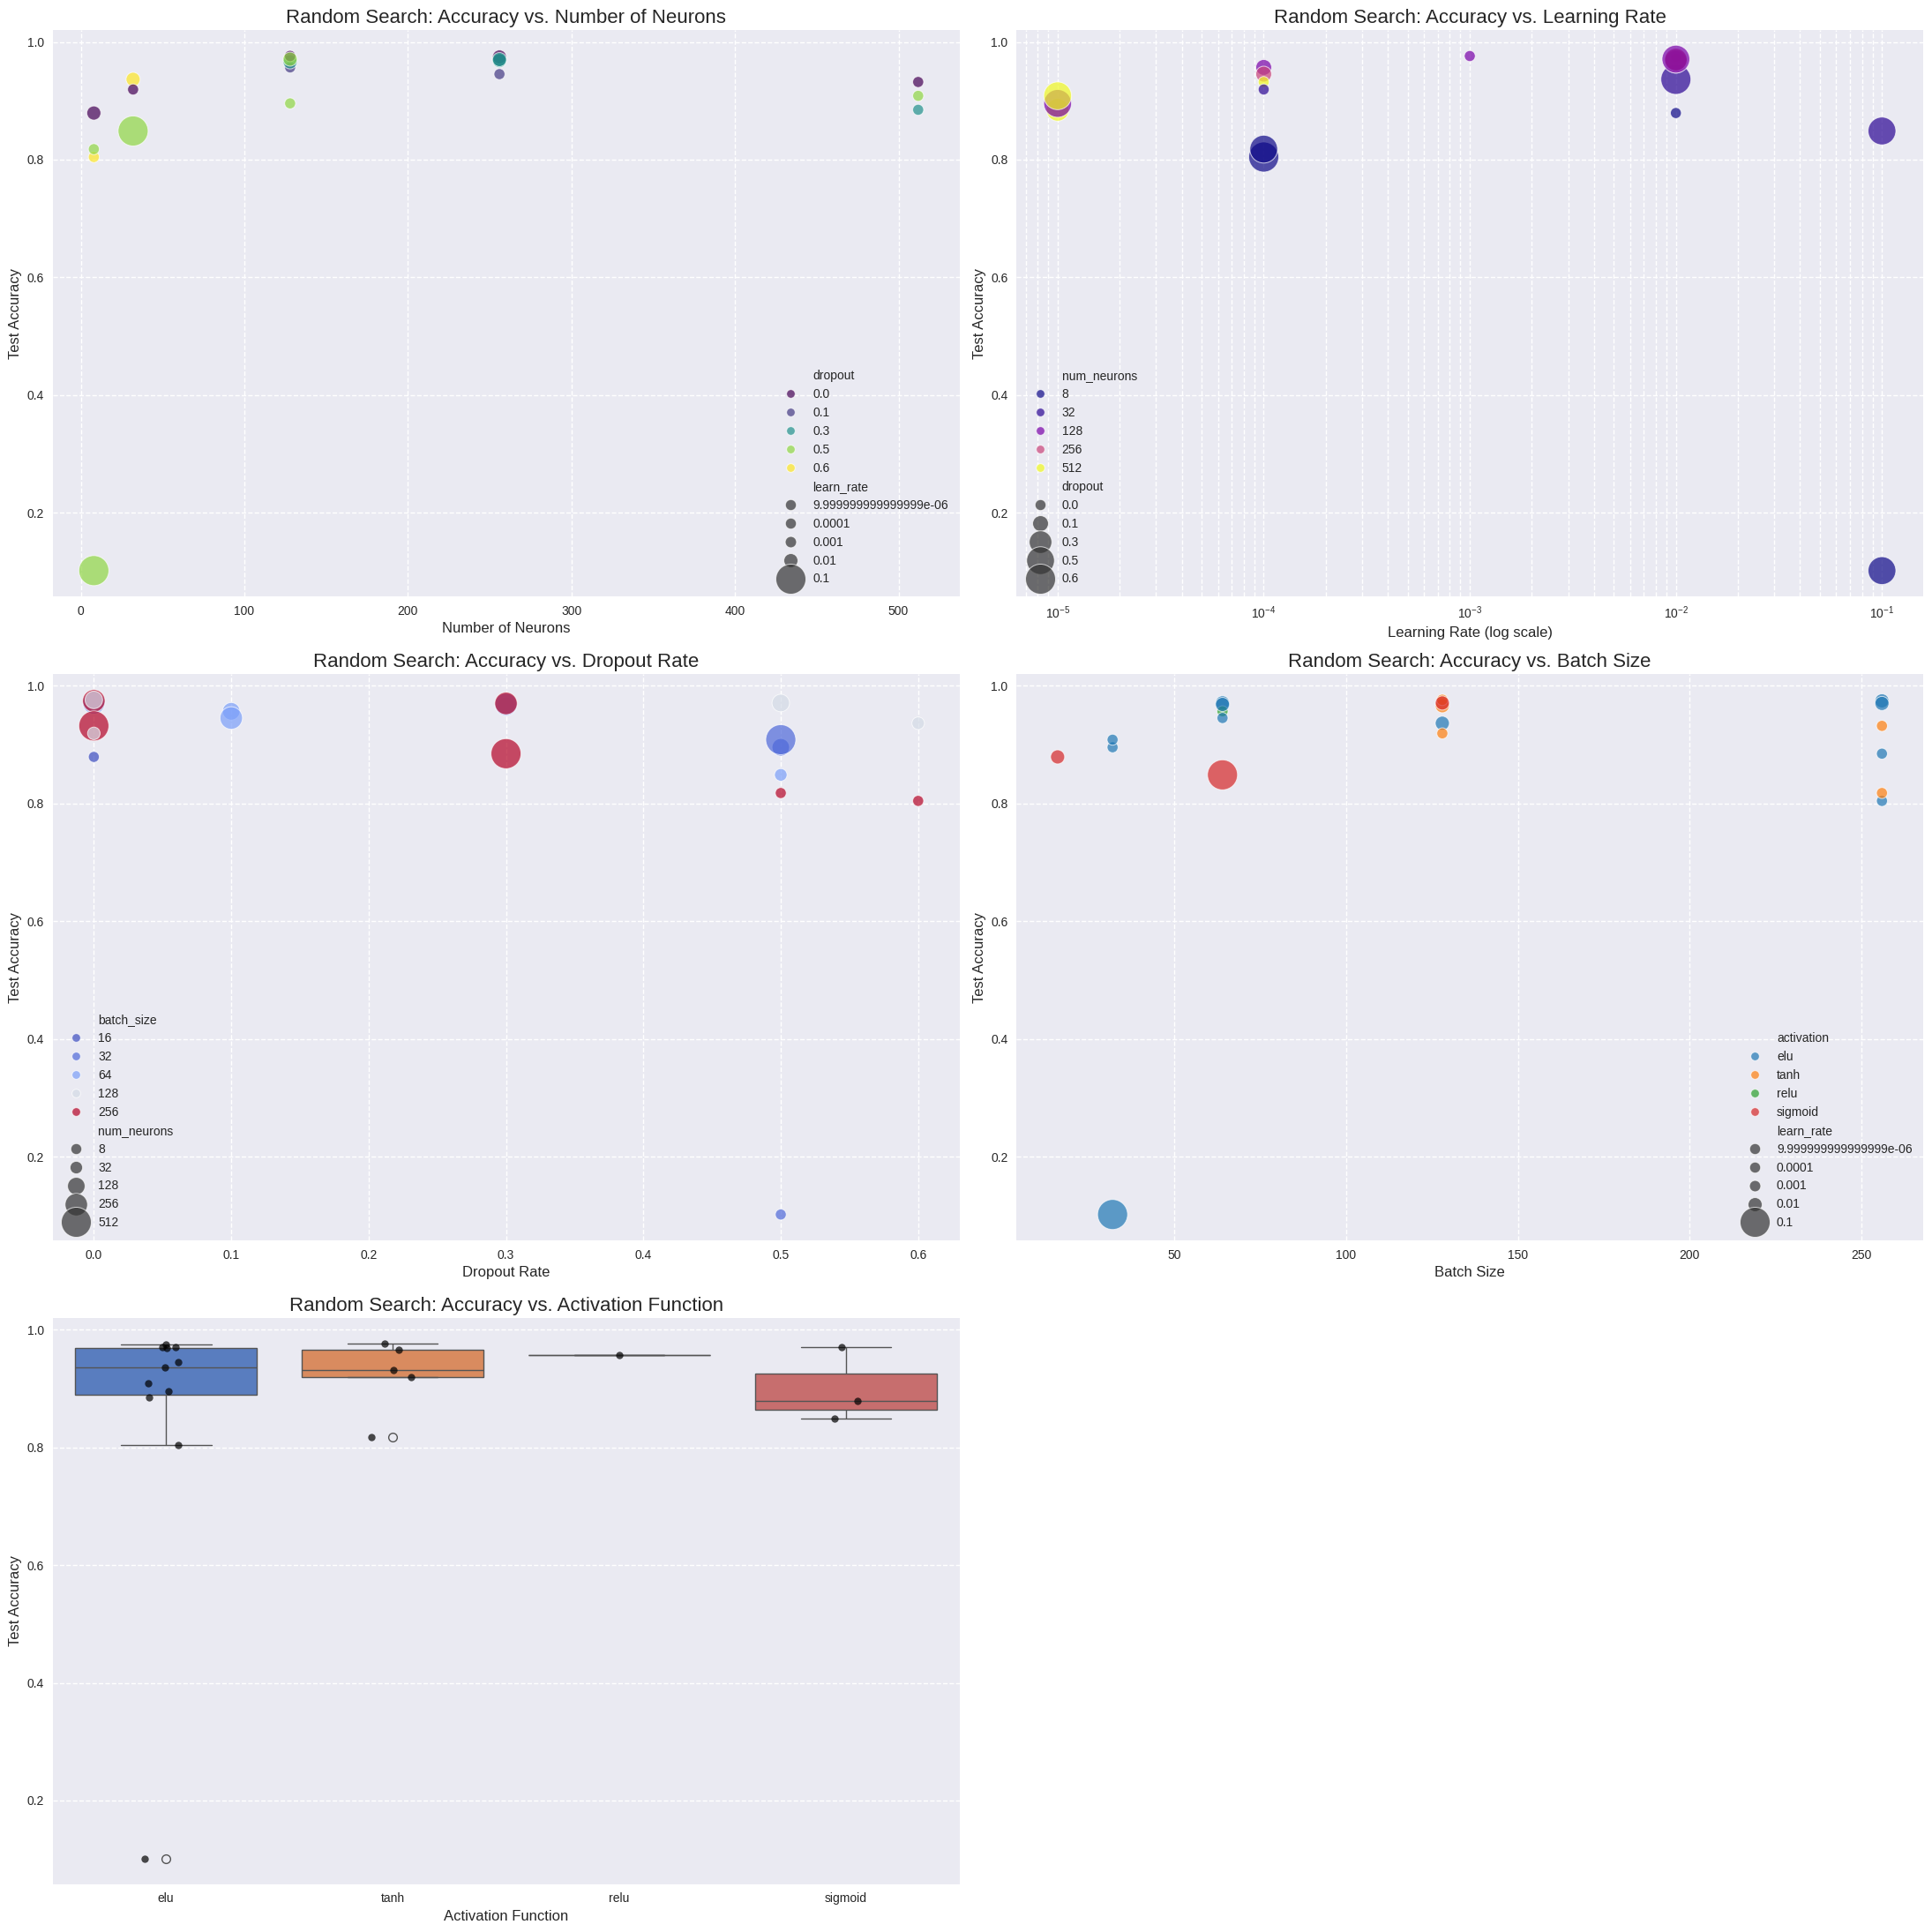

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame from the search results for easier plotting
df_search = pd.DataFrame({
    'batch_size': search['batch_size'],
    'num_neurons': search['num_neurons'],
    'learn_rate': 10.0**search['learn_rate'], # Convert log10 back to actual learning rate
    'activation': search['activation'],
    'dropout': search['dropout'],
    'val_acc': search['val_acc']
})

# Set up the figure and axes for multiple plots, increasing figsize for better readability
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(22, 22)) # Increased figure size
axes = axes.flatten() # Flatten the 2x3 array of axes for easy iteration

# Plot 1: Accuracy vs. Number of Neurons
sns.scatterplot(x='num_neurons', y='val_acc', hue='dropout', size='learn_rate', palette='viridis', data=df_search, ax=axes[0], sizes=(80, 600), alpha=0.7)
axes[0].set_title('Random Search: Accuracy vs. Number of Neurons', fontsize=16)
axes[0].set_xlabel('Number of Neurons', fontsize=12)
axes[0].set_ylabel('Test Accuracy', fontsize=12)
axes[0].tick_params(axis='both', which='major', labelsize=10)
axes[0].grid(True, ls='--')

# Plot 2: Accuracy vs. Learning Rate
sns.scatterplot(x='learn_rate', y='val_acc', hue='num_neurons', size='dropout', palette='plasma', data=df_search, ax=axes[1], sizes=(80, 600), alpha=0.7)
axes[1].set_xscale('log')
axes[1].set_title('Random Search: Accuracy vs. Learning Rate', fontsize=16)
axes[1].set_xlabel('Learning Rate (log scale)', fontsize=12)
axes[1].set_ylabel('Test Accuracy', fontsize=12)
axes[1].tick_params(axis='both', which='major', labelsize=10)
axes[1].grid(True, which="both", ls='--')

# Plot 3: Accuracy vs. Dropout Rate
sns.scatterplot(x='dropout', y='val_acc', hue='batch_size', size='num_neurons', palette='coolwarm', data=df_search, ax=axes[2], sizes=(80, 600), alpha=0.7)
axes[2].set_title('Random Search: Accuracy vs. Dropout Rate', fontsize=16)
axes[2].set_xlabel('Dropout Rate', fontsize=12)
axes[2].set_ylabel('Test Accuracy', fontsize=12)
axes[2].tick_params(axis='both', which='major', labelsize=10)
axes[2].grid(True, ls='--')

# Plot 4: Accuracy vs. Batch Size
sns.scatterplot(x='batch_size', y='val_acc', hue='activation', size='learn_rate', palette='tab10', data=df_search, ax=axes[3], sizes=(80, 600), alpha=0.7)
axes[3].set_title('Random Search: Accuracy vs. Batch Size', fontsize=16)
axes[3].set_xlabel('Batch Size', fontsize=12)
axes[3].set_ylabel('Test Accuracy', fontsize=12)
axes[3].tick_params(axis='both', which='major', labelsize=10)
axes[3].grid(True, ls='--')

# Plot 5: Accuracy vs. Activation Function (Categorical)
sns.boxplot(x='activation', y='val_acc', palette='muted', data=df_search, ax=axes[4], hue='activation', legend=False)
sns.stripplot(x='activation', y='val_acc', color='black', size=6, jitter=True, data=df_search, ax=axes[4], alpha=0.7) # Increased point size for stripplot
axes[4].set_title('Random Search: Accuracy vs. Activation Function', fontsize=16)
axes[4].set_xlabel('Activation Function', fontsize=12)
axes[4].set_ylabel('Test Accuracy', fontsize=12)
axes[4].tick_params(axis='both', which='major', labelsize=10)
axes[4].grid(True, axis='y', ls='--')

# Hide the last unused subplot if ncols is odd and nrows*ncols > number of plots
if len(axes) > 5:
    fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

## Analysis of Random Search Results

The random search results show that different hyperparameters influenced the model performance in different ways, and their relationship with test accuracy was not always linear.

From the plots, it can be observed that increasing the **number of neurons** generally improved the test accuracy, with some of the highest accuracies seen with **128 and 256 neurons (e.g., up to 0.976)**. However, increasing the number of neurons alone did not always guarantee better performance, since some larger networks still resulted in lower accuracies due to the interaction with other hyperparameters such as learning rate and dropout.

The **learning rate** had a significant effect on model performance. Very high learning rates, such as (`10^-1`), often produced lower accuracies because the optimization process became unstable and overshot the minimum during training. In contrast, moderate learning rates around (`10^-3`) to (`10^-2`) generally resulted in higher accuracies and more stable convergence.

The **dropout rate** also affected the results noticeably. Moderate dropout values produced more stable and higher accuracies, while very high dropout rates sometimes reduced performance. This is likely because excessive dropout removes too much information during training and limits the learning capability of the network. Smaller dropout values, on the other hand, helped reduce overfitting while still preserving useful features.

The **batch size** comparison suggests that medium to larger batch sizes often achieved slightly better accuracies, although the differences were not extremely large. In addition, the activation function boxplot indicates that `tanh` and `sigmoid` produced slightly more stable and higher median accuracies in this experiment, while `relu` showed larger variation between runs.

### Effect of Activation Functions

The activation function comparison shows that different activation functions produced different levels of stability and accuracy during training. From the boxplot, **`tanh`** achieved some of the highest accuracies and showed relatively stable performance across different runs. **`Sigmoid`** also performed reasonably well in several cases, although its results showed larger variation and some lower-performing runs.

**`ReLU`**, despite being one of the most commonly used activation functions in deep learning, the random search didnt include much of relu´s. Hence, we cannot say much about it

. Overall, the results suggest that for the MNIST dataset, smoother activation functions such as **`tanh`** performed slightly more consistently during the random search experiment. However, the differences between activation functions were not extremely large, indicating that the overall model performance depended more on the combination of hyperparameters rather than the activation function alone.

Overall, certain combinations of neuron size, learning rate, dropout, batch size, and activation function achieved accuracies close to **97.6% (e.g., `val_acc` of 0.976125 for the best random search run)**, showing that careful hyperparameter tuning can significantly improve model performance even for relatively simple datasets such as MNIST.

In [ ]:
# Sort the DataFrame by 'val_acc' in descending order and display the top 5
top_5_combinations = df_search.sort_values(by='val_acc', ascending=False).head(5)
display(top_5_combinations)

,batch_size,num_neurons,learn_rate,activation,dropout,val_acc
14,128,128,0.001,tanh,0.0,0.976125
9,256,256,0.010,elu,0.0,0.974500
2,64,256,0.010,elu,0.0,0.971125
16,128,128,0.010,sigmoid,0.5,0.970875
12,256,256,0.010,elu,0.3,0.970125


Again these results are from random search, which didnt include all possible combinations as grid search do. In grid search for two hyperparameters, we indeed touch 0.98 accuracy, but in random search we also got good accuracy with appropriate test loss values.

### Correlation Heatmap of Hyperparameters and Accuracy

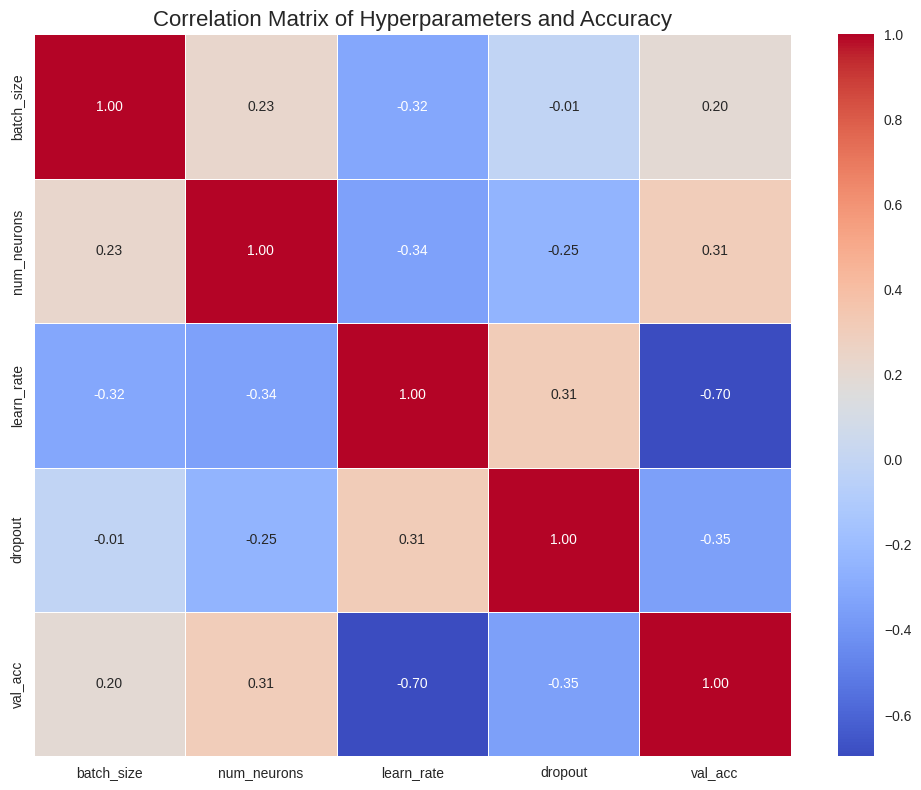

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation calculation
# Exclude 'activation' as it's categorical and requires different handling for correlation
correlation_data = df_search[['batch_size', 'num_neurons', 'learn_rate', 'dropout', 'val_acc']]

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Hyperparameters and Accuracy', fontsize=16)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()


**Interpretation of the Correlation Heatmap:**

*   **`val_acc` (Validation Accuracy) Correlations:**
    *   **Positive Correlations:** `num_neurons` (**0.31**) and `batch_size` (**0.20**) show a positive correlation with validation accuracy. This suggests that generally, higher numbers of neurons and larger batch sizes tend to be associated with better accuracy, though the correlation is moderate.
    *   **Negative Correlations:** `learn_rate` (**-0.70**) has the strongest negative correlation with `val_acc`. This indicates that higher learning rates are often associated with lower validation accuracy, which is a common observation in neural network training, as very high learning rates can cause training to diverge or oscillate.
    *   **Weak/Negligible Correlations:** `dropout` (**-0.35**) shows a moderate negative correlation with `val_acc`. This might imply that within the tested range, increasing dropout tends to slightly decrease accuracy, or its optimal value is not strictly at the extremes.

*   **Inter-Hyperparameter Correlations:**
    *   Most hyperparameters show relatively weak correlations with each other, which is good for hyperparameter tuning as it means their effects are somewhat independent and not collinear. For example, `learn_rate` is not strongly correlated with `dropout` or `num_neurons`.

In summary, the heatmap highlights that `learning rate` has the most significant linear relationship with accuracy (inversely), followed by `num_neurons` and `batch_size` (positively). The `dropout` rate appears to have a less direct linear impact on accuracy across the search space.

In [ ]:
pip install -q keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 5.9 MB/s eta 0:00:00


### Enable GPU for Faster Training

If you have a GPU available in your Colab environment, enabling it can drastically speed up the training of neural networks. The following code checks for and configures TensorFlow to use an available GPU.

In [ ]:
import tensorflow as tf

print("Num GPUs Available: ", len(tf.config.experimental.list_physical_devices('GPU')))

# Check if a GPU is available and set it as the default device
if tf.config.experimental.list_physical_devices('GPU'):
    try:
        # Set memory growth to avoid allocating all GPU memory at once
        for gpu in tf.config.experimental.list_physical_devices('GPU'):
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(logical_gpus), "Logical GPUs")
        print("GPU is available and configured.")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("No GPU available, using CPU.")

Num GPUs Available:  1
1 Logical GPUs
GPU is available and configured.


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Starting analysis of 'how many trials are necessary' using Random Search...

Running 3 repetitions for max_trials=5...
  Repetition 1/3 for max_trials=5...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


  Repetition 2/3 for max_trials=5...
  Repetition 3/3 for max_trials=5...

Running 3 repetitions for max_trials=10...
  Repetition 1/3 for max_trials=10...
  Repetition 2/3 for max_trials=10...
  Repetition 3/3 for max_trials=10...

Running 3 repetitions for max_trials=20...
  Repetition 1/3 for max_trials=20...
  Repetition 2/3 for max_trials=20...
  Repetition 3/3 for max_trials=20...

Running 3 repetitions for max_trials=30...
  Repetition 1/3 for max_trials=30...
  Repetition 2/3 for max_trials=30...
  Repetition 3/3 for max_trials=30...

Analysis complete. Plotting results...


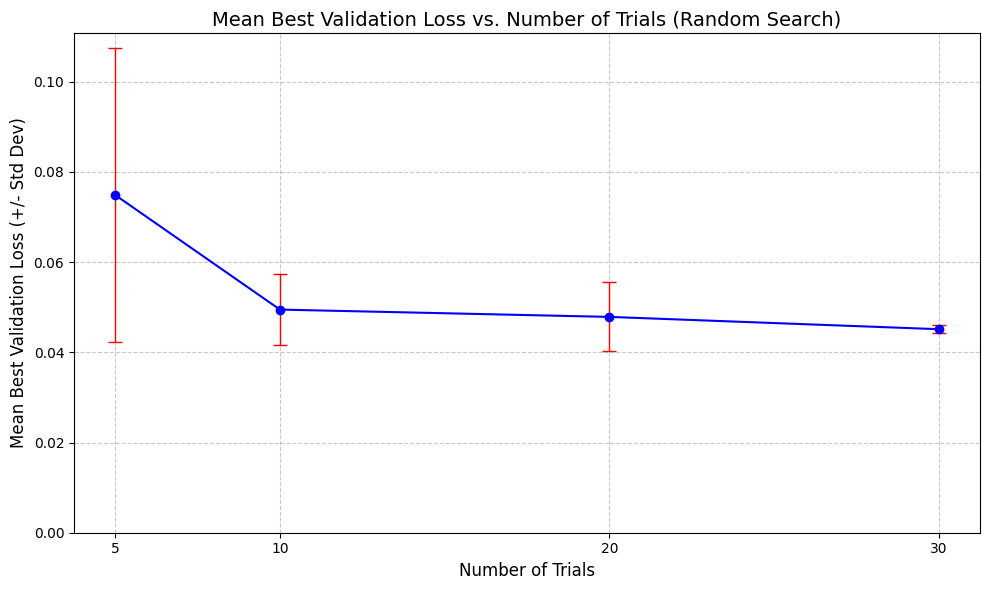


Summary of results:
  For 5 trials: Mean Best Val Loss = 0.0749 +/- 0.0325
  For 10 trials: Mean Best Val Loss = 0.0495 +/- 0.0079
  For 20 trials: Mean Best Val Loss = 0.0479 +/- 0.0077
  For 30 trials: Mean Best Val Loss = 0.0451 +/- 0.0009


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import keras_tuner as kt
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Data Loading and Initial Preprocessing (from previous cells) ---
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Split validation set
x_valid = x_test[8000:]
y_valid = y_test[8000:]
x_test = x_test[:8000]
y_test = y_test[:8000]

# Reshape images to vectors
x_train = x_train.reshape(-1, 28**2)
x_valid = x_valid.reshape(-1, 28**2)
x_test = x_test.reshape(-1, 28**2)

# One-hot encode labels
y_train_onehot = tf.keras.utils.to_categorical(y_train, 10)
y_valid_onehot = tf.keras.utils.to_categorical(y_valid, 10)
y_test_onehot = tf.keras.utils.to_categorical(y_test, 10)

# Apply data normalization (0-255 to 0-1 range)
x_train_norm = x_train.astype('float32') / 255.0
x_valid_norm = x_valid.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0


# Re-define the build_model function to ensure it's available in this cell's scope
# This function will define the hyperparameters to be tuned by RandomSearch
def build_model(hp):
    model = tf.keras.models.Sequential()

    # Number of neurons in the first (and only) hidden layer
    # Using choices from the previous random search (8, 32, 128, 256, 512)
    hp_num_neurons = hp.Choice('num_neurons', values=[8, 32, 128, 256, 512])
    model.add(layers.Dense(units=hp_num_neurons, input_shape=(784,)))

    # Activation function
    hp_activation = hp.Choice('activation', values=['relu', 'elu', 'sigmoid', 'tanh'])
    model.add(layers.Activation(hp_activation))

    # Dropout rate
    hp_dropout = hp.Float('dropout', min_value=0.0, max_value=0.6, step=0.1)
    if hp_dropout > 0:
        model.add(layers.Dropout(hp_dropout))

    model.add(layers.Dense(10, activation='softmax'))

    # Learning rate for the optimizer
    hp_learning_rate = hp.Float('learning_rate', min_value=1e-5, max_value=1e-1, sampling='log')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


# Define the range of max_trials values to investigate
max_trials_values = [5, 10, 20, 30]
# Define the number of repetitions for each max_trials value
num_repetitions = 3
# Define batch size choices to be randomly sampled for each repetition
batch_size_choices = [16, 32, 64, 128, 256]

results_mean_loss = []
results_std_loss = []

print("Starting analysis of 'how many trials are necessary' using Random Search...")

for num_trials in max_trials_values:
    print(f"\nRunning {num_repetitions} repetitions for max_trials={num_trials}...")
    best_losses_for_num_trials = []

    for rep in range(num_repetitions):
        print(f"  Repetition {rep+1}/{num_repetitions} for max_trials={num_trials}...")
        tf.keras.backend.clear_session() # Clear session before each new tuner run

        # Randomly select a batch_size for this repetition
        current_batch_size = np.random.choice(batch_size_choices)

        # Create a unique directory for each tuner run to avoid conflicts
        project_name = f'mnist_random_search_trials_analysis_trials_{num_trials}_rep_{rep}'
        tuner_dir = os.path.join('keras_tuner_trials_analysis_rs', project_name)

        # Instantiate the RandomSearch tuner
        tuner_rep = kt.RandomSearch(
            hypermodel=build_model,
            objective='val_loss', # Objective is validation loss (to be minimized)
            max_trials=num_trials,
            executions_per_trial=1,
            directory=tuner_dir,
            project_name=project_name,
            overwrite=True
        )

        # Run the search for the current number of trials and repetition
        tuner_rep.search(
            x_train_norm, y_train_onehot,
            epochs=10,
            validation_data=(x_valid_norm, y_valid_onehot),
            batch_size=current_batch_size, # Use the randomly chosen batch size for this repetition
            verbose=0 # Suppress verbose output from model.fit
        )

        # Get the best trial's validation loss
        # best_hps_rep = tuner_rep.get_best_hyperparameters(num_trials=1)[0]
        # best_val_loss = best_hps_rep.score # The 'score' holds the objective value (val_loss)
        # Note: 'score' is for best hyperparameters, not directly the best model score.
        # To get the best validation loss from the best model, we retrieve its score.
        best_model_trial = tuner_rep.get_best_models(num_models=1)[0]
        best_val_loss = best_model_trial.evaluate(x_valid_norm, y_valid_onehot, verbose=0)[0] # Get validation loss from best model

        best_losses_for_num_trials.append(best_val_loss)

    # Calculate mean and standard deviation for the current num_trials
    results_mean_loss.append(np.mean(best_losses_for_num_trials))
    results_std_loss.append(np.std(best_losses_for_num_trials))

print("\nAnalysis complete. Plotting results...")

# Plotting the results
plt.figure(figsize=(10, 6))
plt.errorbar(max_trials_values, results_mean_loss, yerr=results_std_loss, fmt='-o', capsize=5, color='blue', ecolor='red', elinewidth=1, capthick=1)
plt.title('Mean Best Validation Loss vs. Number of Trials (Random Search)', fontsize=14)
plt.xlabel('Number of Trials', fontsize=12)
plt.ylabel('Mean Best Validation Loss (+/- Std Dev)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(max_trials_values, fontsize=10)
plt.yticks(fontsize=10)
plt.ylim(bottom=0) # Ensure y-axis starts from 0 or slightly below min loss
plt.tight_layout()
plt.show()

print("\nSummary of results:")
for i, num_trials in enumerate(max_trials_values):
    print(f"  For {num_trials} trials: Mean Best Val Loss = {results_mean_loss[i]:.4f} +/- {results_std_loss[i]:.4f}")

## Analysis of 'Trials Needed' for Random Search

The analysis of 'Mean Best Validation Loss vs. Number of Trials' provides valuable insights into the efficiency of our random search strategy:

*   **Initial Improvement (5 to 10 trials):** We observe a significant decrease in the mean best validation loss when moving from 5 trials (**0.0749**) to 10 trials (**0.0495**). This indicates that even a small increase in the number of trials can lead to finding substantially better hyperparameter combinations initially.

*   **Plateauing or Local Fluctuations (10 to 30 trials):** After 10 trials, the mean best validation loss continues to decrease but at a slower rate. For instance, it moves from **0.0495** (10 trials) to **0.0479** (20 trials) and then to **0.0451** (30 trials). This suggests that for this specific problem and hyperparameter search space, a significant portion of the 'good' configurations might be found relatively early, with diminishing returns for more trials.

*   **Standard Deviation as an Indicator of Stability:** The standard deviation (yerr in the plot) shows the variability of the best validation loss across the 3 repetitions for each `max_trials` value. A smaller standard deviation suggests that the search process is more consistently finding similar quality solutions. We can see that the standard deviation is relatively small for 10, 20 and 30 trials, indicating a certain level of consistency.

### Conclusion

Based on these results, to find a reasonably good set of hyperparameters for this model and dataset, around **10-30 trials** with random search seem to be effective. While increasing trials further might incrementally improve the mean best loss, the returns diminish. If the goal is to consistently find a near-optimal solution, more trials would be beneficial, and advanced methods like Bayesian Optimization would be more efficient for larger search spaces or when computational resources are limited.

### Explanation for 20 Trials Performing Worse than 10 Trials

While the general expectation is that more trials should lead to finding better or at least comparable hyperparameter combinations (resulting in a lower or equal best validation loss), the observed results show a general decreasing trend, with slight fluctuations. This is likely due to the following reasons:

1.  **Randomness of Random Search:** As the name suggests, random search selects hyperparameter combinations randomly. In any given set of trials, there's always an element of chance. It's possible that, purely by chance, the *specific random combinations* explored during some of the runs were, on average, less optimal or had a higher minimum validation loss than the combinations explored during other runs. The search space for each set of trials (e.g., for `max_trials=10` vs. `max_trials=20`) is resampled anew from the hyperparameter ranges, not a continuation.

2.  **Limited Number of Repetitions:** We performed 3 repetitions for each `max_trials` value. While this helps provide a mean and standard deviation, 3 repetitions are still a relatively small sample size. With more repetitions (e.g., 10 or 20), such an anomaly would likely smooth out, and we would expect to see a more consistent trend where the mean best loss either decreases or plateaus as the number of trials increases. A single 'unlucky' set of random hyperparameter choices in one of the repetitions could significantly skew the average.

3.  **Focus on 'Best' Loss:** The metric we are tracking is the *best* validation loss found within those `N` trials. Even if more trials increase the *overall chance* of finding a good solution, it doesn't guarantee that the *best solution found* in a larger set of random trials will always be strictly better than the best found in a smaller set, especially when the total number of trials is still relatively small, and the search space is vast and complex.

In essence, this is a statistical fluctuation. If we were to run this entire analysis many more times, we would likely see that the average best loss for more trials converges to a value that is either better than or equal to that of fewer trials. However, with only 3 repetitions, these kinds of localized 'bumps' or non-monotonic behaviors can appear.

### How many trials needed?
To find a 'good enough' combination: We've likely already found several good combinations within the **30 trials** conducted. If our goal is to achieve strong performance without necessarily finding the absolute theoretical optimum, we might already have sufficient results.

To find a 'better' combination: we would typically need more trials. For a dataset like MNIST and a neural network of this complexity, extending the random search to **50-100 trials** would be a reasonable next step if computational resources allow.

To find the 'best possible' combination (or closer to it): This would almost certainly require more than 100 trials and would greatly benefit from more advanced hyperparameter optimization techniques like Bayesian Optimization (using libraries like Keras Tuner). These methods intelligently choose the next best hyperparameters to try, learning from previous results, and are much more efficient than pure random search for finding near-optimal solutions with fewer evaluations.

## Bayesian Optimization for Hyperparameter Tuning

We will use `keras-tuner` to perform Bayesian Optimization. This method intelligently explores the hyperparameter space by building a probabilistic model of the objective function (e.g., validation accuracy) based on past evaluation results. This allows it to suggest more promising hyperparameter combinations to test next, leading to finding optimal configurations more efficiently than random search.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
import keras_tuner as kt

# Define the model-building function for Keras Tuner
def build_model(hp):
    model = tf.keras.models.Sequential()

    # Number of neurons in the first (and only) hidden layer
    hp_num_neurons = hp.Int('num_neurons', min_value=8, max_value=512, step=32, sampling='log')
    model.add(layers.Dense(units=hp_num_neurons, input_shape=(784,)))

    # Activation function
    hp_activation = hp.Choice('activation', values=['relu', 'elu', 'sigmoid', 'tanh'])
    model.add(layers.Activation(hp_activation))

    # Dropout rate
    hp_dropout = hp.Float('dropout', min_value=0.0, max_value=0.6, step=0.1)
    if hp_dropout > 0:
        model.add(layers.Dropout(hp_dropout))

    model.add(layers.Dense(10, activation='softmax'))

    # Learning rate for the optimizer
    hp_learning_rate = hp.Float('learning_rate', min_value=1e-5, max_value=1e-1, sampling='log')

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Instantiate the BayesianOptimization tuner
tuner = kt.BayesianOptimization(
    hypermodel=build_model,
    objective='val_accuracy',
    max_trials=20, # Number of hyperparameter combinations to test
    executions_per_trial=1, # Number of times to train each model for robustness
    directory='keras_tuner_dir', # Directory to save results
    project_name='mnist_bayesian_optimization',
    overwrite=True
)

print("Starting Bayesian Optimization search...")
# Run the search
tuner.search(
    x_train_norm, y_train_onehot,
    epochs=10,
    validation_data=(x_valid_norm, y_valid_onehot),
    batch_size=32, # Batch size will be fixed for now, can be tuned later if needed
    verbose=0 # Suppress verbose output from model.fit
)

print("Search complete. Getting best hyperparameters...")
# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Best Hyperparameters found by Bayesian Optimization:")
print(f"- Number of Neurons: {best_hps.get('num_neurons')}")
print(f"- Activation Function: {best_hps.get('activation')}")
print(f"- Dropout Rate: {best_hps.get('dropout')}")
print(f"- Learning Rate: {best_hps.get('learning_rate')}")

# Build the best model and evaluate it on the test set
best_model = tuner.get_best_models(num_models=1)[0]
loss, accuracy = best_model.evaluate(x_test_norm, y_test_onehot, verbose=0)
print(f"\nBest model's test loss: {loss:.4f}")
print(f"Best model's test accuracy: {accuracy:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting Bayesian Optimization search...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr

Search complete. Getting best hyperparameters...
Best Hyperparameters found by Bayesian Optimization:
- Number of Neurons: 256
- Activation Function: elu
- Dropout Rate: 0.30000000000000004
- Learning Rate: 0.001949124380805685


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Best model's test loss: 0.0967
Best model's test accuracy: 0.9761


## Bayesian Optimization Results Summary

After running **20 trials** with Bayesian Optimization using `keras-tuner`, the following best hyperparameters were found:
*   **Number of Neurons:** **256**
*   **Activation Function:** **elu**
*   **Dropout Rate:** **0.30**
*   **Learning Rate:** **~0.0019**

The best model resulting from this search achieved a test accuracy of **0.9761** and a test loss of **0.0967**.

### Comparison with Grid Search

For comparison, the Grid Search (also conducted with a similar number of trials) found its best performance with:

*   **Number of Neurons:** **512**
*   **Dropout Rate:** **0.40**

This combination yielded a test accuracy of approximately **0.980**.

### Conclusion

In this specific scenario with a limited number of trials (20), the Bayesian Optimization (`0.9761`) is comparable to the Grid Search (`0.980`). While Bayesian Optimization is theoretically more efficient in exploring the hyperparameter space, a small number of trials might not always be enough for it to fully leverage its intelligent search capabilities and surpass a well-designed grid search. To truly demonstrate the efficiency and potential superior performance of Bayesian Optimization, a larger number of trials would typically be beneficial, allowing it to more thoroughly explore the promising regions of the hyperparameter space.